In [1]:
from helper_functions_MTL_IFE import build_dataloaders, build_model, train_model, plot_history, evaluate_model

Epoch 1/30 | Train: 36.77% | Val: 40.79% | LR: 0.000100
Epoch 2/30 | Train: 45.42% | Val: 45.93% | LR: 0.000100
Epoch 3/30 | Train: 51.48% | Val: 50.81% | LR: 0.000100
Epoch 4/30 | Train: 53.94% | Val: 53.93% | LR: 0.000100
Epoch 5/30 | Train: 57.81% | Val: 54.47% | LR: 0.000100
Epoch 6/30 | Train: 61.88% | Val: 57.32% | LR: 0.000100
Epoch 7/30 | Train: 63.92% | Val: 56.23% | LR: 0.000100
Epoch 8/30 | Train: 69.35% | Val: 56.78% | LR: 0.000100
Epoch 9/30 | Train: 71.94% | Val: 56.37% | LR: 0.000050
Epoch 10/30 | Train: 77.86% | Val: 57.05% | LR: 0.000050
Epoch 11/30 | Train: 80.61% | Val: 56.91% | LR: 0.000050
Epoch 12/30 | Train: 82.60% | Val: 55.28% | LR: 0.000025
Epoch 13/30 | Train: 87.27% | Val: 55.28% | LR: 0.000025
Epoch 14/30 | Train: 88.78% | Val: 56.50% | LR: 0.000025
Epoch 15/30 | Train: 90.49% | Val: 56.64% | LR: 0.000013
Epoch 16/30 | Train: 91.27% | Val: 56.78% | LR: 0.000013
Epoch 17/30 | Train: 92.09% | Val: 56.10% | LR: 0.000013
Epoch 18/30 | Train: 92.53% | Val: 57.18

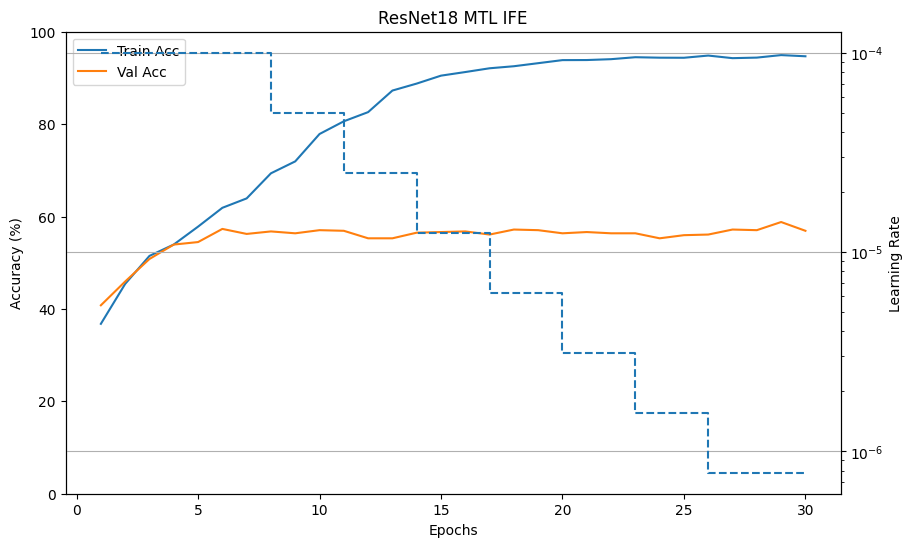


Final Test Accuracy: 65.72%


In [3]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="resnet18",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=30,
    alpha=0.3
)

plot_history(history, "ResNet18 MTL IFE")

test_accuracy = evaluate_model(model, test_loader)